# Demo B: real-world supine breast MRI data


One slice from a T2w TSE sequence with free-breathing and physiological data recorded with a pneumatic respiratory belt.

Isaieva et al. MRM 2023, https://doi.org/10.1002/mrm.29768


[Demo B] Found dataset: data/demo_breast_data.h5
[Demo B] Loading config...
[Demo B] Initializing runtime...
[Demo B] Loading data and building operators...
[DataLoader] k-space normalized (rms), scale=4.011742e-05


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

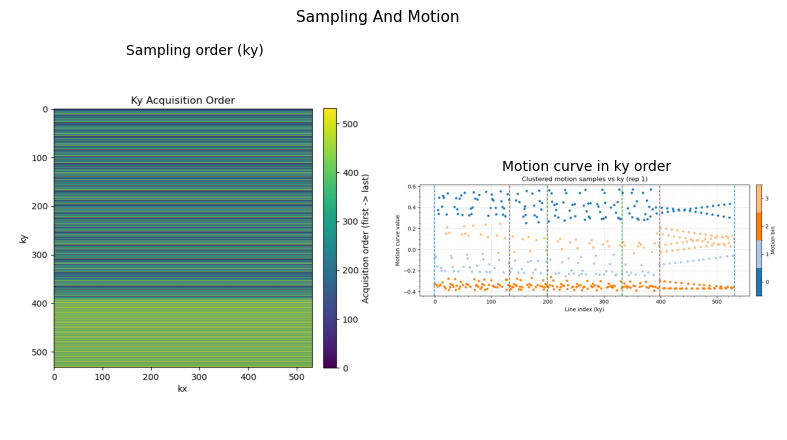

[Demo B] Starting reconstruction...


Resolution level 1/3:   0%|          | 0/10 [00:00<?, ?it/s]

Resolution level 2/3:   0%|          | 0/4 [00:00<?, ?it/s]

Resolution level 3/3:   0%|          | 0/4 [00:00<?, ?it/s]

Elapsed time: 22.47 s


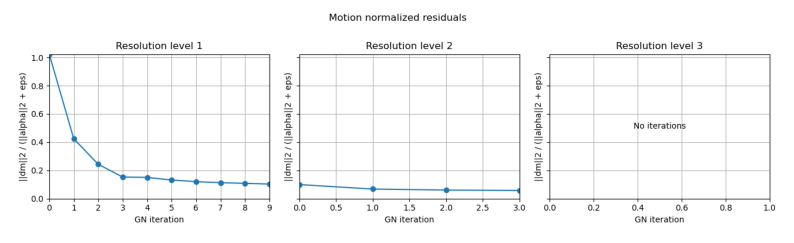

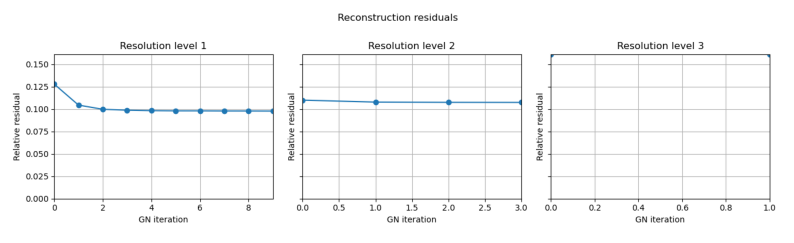

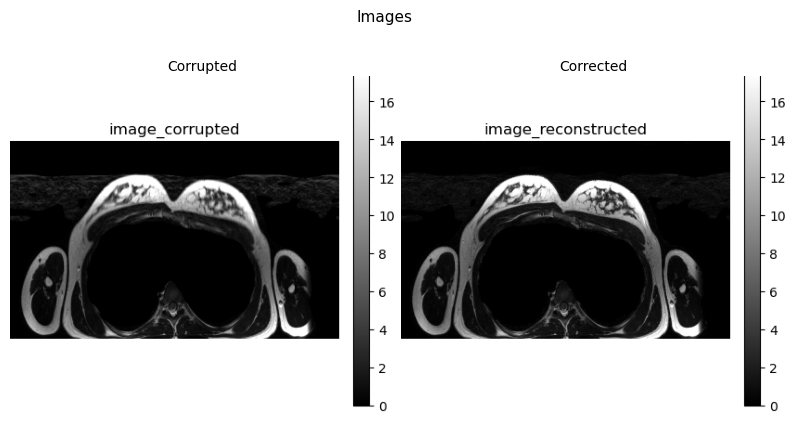

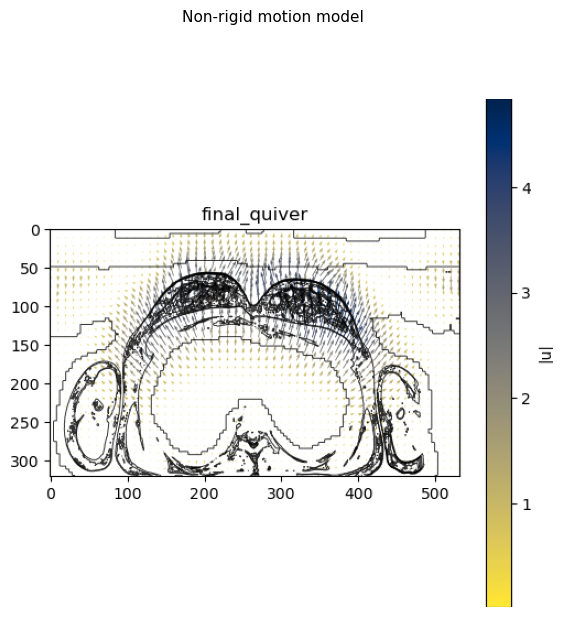

In [1]:
import time
from pathlib import Path
from urllib.request import urlretrieve

from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.utils.notebook_display import display_input_sampling_motion_panels, display_run_panels
from src.runtime.runtime_setup import initialize_runtime

jupyter_notebook_flag = True

DATA_FILE = Path("data/demo_breast_data.h5")
DATA_URL = "https://zenodo.org/records/19086853/files/demo_breast_data.h5?download=1"


def ensure_demo_b_data() -> None:
    if DATA_FILE.exists():
        print(f"[Demo B] Found dataset: {DATA_FILE}")
        return

    print(f"[Demo B] Dataset not found at {DATA_FILE}; downloading...")
    DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(DATA_URL, DATA_FILE)
    print(f"[Demo B] Download complete: {DATA_FILE}")


def main():
    ensure_demo_b_data()

    print("[Demo B] Loading config...")
    params = load_config(
        data_type="real-world",
        reconstruction_config="config/reconstruction/nonrigid_2d.toml",
        overrides={
            "jupyter_notebook_flag": jupyter_notebook_flag,
        },
    )

    print("[Demo B] Initializing runtime...")
    sp_device, t_device = initialize_runtime(params)

    print("[Demo B] Loading data and building operators...")
    data = DataLoader(
        params=params,
        t_device=t_device,
        sp_device=sp_device,
        filename=str(DATA_FILE)
    )
    display_input_sampling_motion_panels(
        params,
    )

    print("[Demo B] Starting reconstruction...")
    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        motion_plot_context=data.motion_plot_context,
    )
    t0 = time.time()
    recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")
    display_run_panels(
        params,
        motion_type=params.reconstruction_motion_type,
    )


if __name__ == "__main__":
    main()

